# Data loading and pre-processing. 

In [1]:
import pandas as pd 
import numpy as np 

import umap 

from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif, mutual_info_classif

import pickle as pk

import seaborn as sns 
import matplotlib.pyplot as plt 

ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']

/Users/sean/Documents/FrancoisLab/venv/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/sean/Documents/FrancoisLab/venv/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/sean/Documents/FrancoisLab/venv/lib/python3.9/site-packag

In [2]:
data = pd.read_hdf("../../TC_Antigen_encoding-main/initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")

In [4]:
selector = SelectKBest(f_classif, k=10)
subsetted_marker_data = selector.fit_transform(data.values, data.index.get_level_values('Peptide'))
MARKERS = list(data.columns[selector.get_support(indices=True)])
MARKERS

['SSC-A',
 'CD25',
 'Granzyme B',
 'CD2',
 'CD27',
 'CD5',
 'CD126',
 'ICOS',
 'IRF8',
 'CD8a']

In [5]:
# Filter the data to the strong antigens, first repliate, OT-1 cells, high concentration, and ALL timepoints. 
df = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                       (data.index.get_level_values('Concentration') == '1uM') & 
                       (data.index.get_level_values('Replicate') == '1') &
                       (data.index.get_level_values('Time') >= 0.0) & # [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
                       (data.index.get_level_values('Peptide').isin(ANTIGENS))
                    ]

df = df[MARKERS]

In [6]:
group_size = 10

def avg(group): 
    group['GroupNumber'] = np.array(range(len(group.index))) // group_size
    res = group.groupby('GroupNumber').mean()
    return res

averaged_df = df.groupby(['Peptide', 'Time']).apply(avg)

In [7]:
antigen = list(averaged_df.index.get_level_values('Peptide'))
time = list(averaged_df.index.get_level_values('Time'))

In [8]:
X = np.array(averaged_df.values)
y = list(map(lambda x: ANTIGENS.index(x), antigen))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [9]:
X_train.shape

(53294, 10)

# Now we fit the UMAP

In [10]:
reducer = umap.UMAP(
    min_dist=0.4, 
    n_neighbors=20, 
    n_components=2, 
    random_state=42
)

In [11]:
train_embedding = reducer.fit_transform( StandardScaler().fit_transform(X_train), y=y_train )

/Users/sean/Documents/FrancoisLab/venv/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
OMP: Info #271: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [12]:
test_embedding = reducer.transform( StandardScaler().fit_transform(X_test) )

# Visualize the Results

Text(0.5, 1.0, 'UMAP over Averaged Data (Ten Markers Only)')

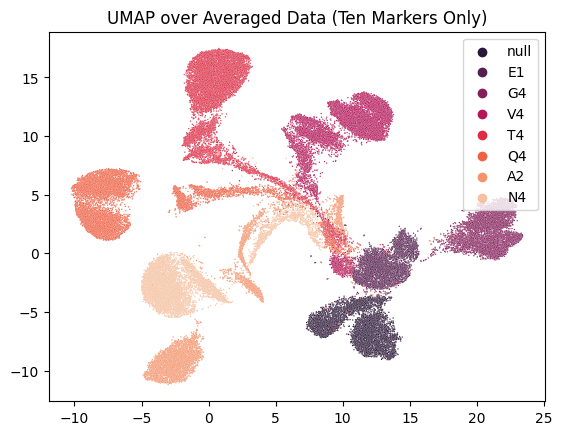

In [13]:
sns.scatterplot(
    x=train_embedding[:,0], 
    y=train_embedding[:,1], 
    hue=pd.Categorical(list(map(lambda x : ANTIGENS[x], y_train))),
    palette="rocket", 
    hue_order=ANTIGENS, 
    s=1
)
plt.title("UMAP over Averaged Data (Ten Markers Only)")

Text(0.5, 1.0, 'UMAP over Averaged Data (Ten Markers Only, Validation)')

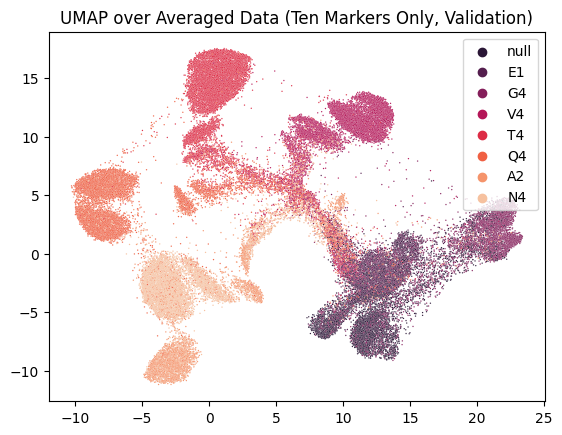

In [14]:
sns.scatterplot(
    x=test_embedding[:,0], 
    y=test_embedding[:,1], 
    hue=pd.Categorical(list(map(lambda x : ANTIGENS[x], y_test))), 
    palette="rocket", 
    hue_order=ANTIGENS,
    s=1
)
plt.title("UMAP over Averaged Data (Ten Markers Only, Validation)")

In [15]:
train_time, test_time = train_test_split(time, test_size=0.5, random_state=42)

Text(0.5, 1.0, 'UMAP over Averaged Data (Ten Markers Only)')

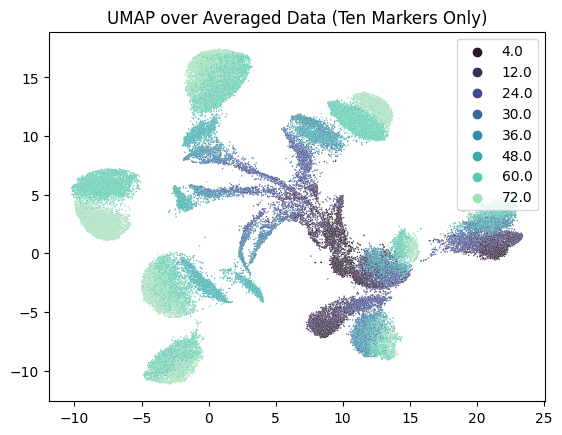

In [20]:
sns.scatterplot(
    x=train_embedding[:,0], 
    y=train_embedding[:,1], 
    hue=pd.Categorical(train_time), 
    palette="mako", 
    s=1
)
plt.title("UMAP over Averaged Data (Ten Markers Only)")

Text(0.5, 1.0, 'UMAP over Averaged Data (Ten Markers Only, Validation)')

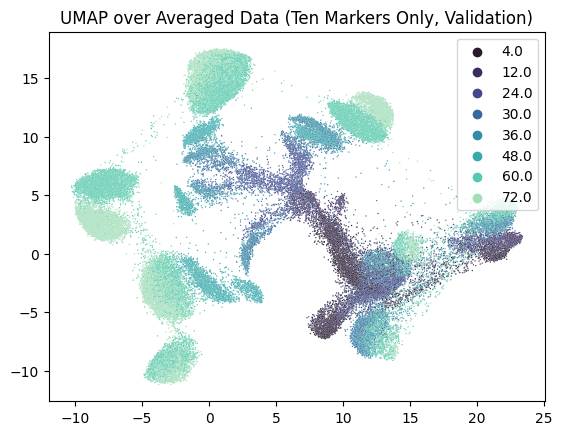

In [22]:
sns.scatterplot(
    x=test_embedding[:,0], 
    y=test_embedding[:,1], 
    hue=pd.Categorical(test_time), 
    palette="mako", 
    s=1
)
plt.title("UMAP over Averaged Data (Ten Markers Only, Validation)")